In [1]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
from astropy.stats import SigmaClip, sigma_clipped_stats
from photutils.background import ModeEstimatorBackground
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
from ccdproc import ImageFileCollection, CCDData, Combiner
import pandas as pd
from tqdm.auto import tqdm

# Para que los plots queden bonitos en notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.origin'] = 'lower'
plt.rcParams['image.cmap'] = 'gray'

print("✅ Todos los paquetes cargados. Listo para empezar.")

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


✅ Todos los paquetes cargados. Listo para empezar.


In [65]:
# ====================== CELDA 1 ======================
# Ruta a tu noche (cámbiala si es necesario)
night_dir = Path("/home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20240314")  # ← AJUSTA

# Usamos ImageFileCollection (la herramienta más potente y rápida)
ifc = ImageFileCollection(location=night_dir, keywords='*')

df = ifc.summary.to_pandas()
df.columns
df["calibf"].value_counts()  

calibf
flat correction    14
Name: count, dtype: int64

In [56]:
df[(df['imagetyp'] == 'object') & (df['object'] != 'bias') 
         & (df['object'] != 'skyflat') & (df['calibf'] == 'flat correction')].iloc[0]

file        FBOGLE-2024-BLG-0034i0001.fit
simple                               True
bitpix                                -64
naxis                                   2
naxis1                               1024
                        ...              
cd2_2                                 NaN
astromet                              NaN
obj_in                                NaN
bscale                                NaN
bzero                                 NaN
Name: 235, Length: 67, dtype: object

Imagen seleccionada: FBobj7i0002.fit
OBJECT = OGLE-2024-BLG-0034 | FILTER = I | EXPTIME = 300.0 s
Tamaño: (1024, 1024) píxeles | Tipo de dato: float64

📈 Estadísticos MANUALES de toda la imagen:
  Media   = 2892.8 ADU
  Mediana = 2859.6 ADU
  Std     = 429.7 ADU
  5%–95%  = 2714 – 3584 ADU


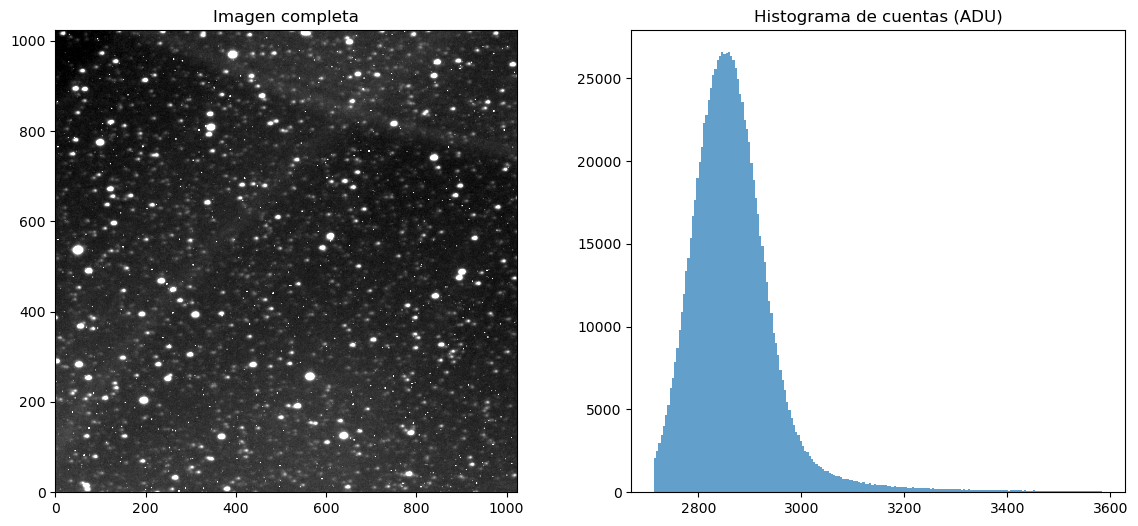

In [74]:
# Elegimos la primera imagen científica 
row = df[(df['imagetyp'] == 'object') & (df['object'] != 'bias') 
         & (df['object'] != 'skyflat') & (df['calibf'] == 'flat correction')].iloc[0]
img_path = night_dir / row['file']

# Leemos datos y header
with fits.open(img_path) as hdul:
    data = hdul[0].data.astype(float)
    header = hdul[0].header

print(f"Imagen seleccionada: {row['file']}")
print(f"OBJECT = {row['object']} | FILTER = {row['filters']} | EXPTIME = {row['exptime']} s")
print(f"Tamaño: {data.shape} píxeles | Tipo de dato: {data.dtype}")

# Estadísticos básicos MANUALES
mean_all   = np.mean(data)
median_all = np.median(data)
std_all    = np.std(data)
p5, p95    = np.percentile(data, [1, 99])

print(f"\n📈 Estadísticos MANUALES de toda la imagen:")
print(f"  Media   = {mean_all:.1f} ADU")
print(f"  Mediana = {median_all:.1f} ADU")
print(f"  Std     = {std_all:.1f} ADU")
print(f"  5%–95%  = {p5:.0f} – {p95:.0f} ADU")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
ax1.imshow(data, vmin=p5, vmax=p95)
ax1.set_title("Imagen completa")
ax2.hist(data.ravel(), bins=200, range=(p5, p95), alpha=0.7)
ax2.set_title("Histograma de cuentas (ADU)")
plt.show()

In [75]:
# Método 1: MANUAL (sigma clipping + mediana)
sigma_clip = SigmaClip(sigma=3.0, maxiters=5)
bkg_manual, bkg_median, _ = sigma_clipped_stats(data, sigma=3.0)
print(f"Fondo manual (sigma-clipped median) = {bkg_median:.2f} ADU")

# Método 2: photutils (el que usa la mayoría de pipelines serios)
bkg_estimator = ModeEstimatorBackground()
bkg_photutils = bkg_estimator.calc_background(data)
print(f"Fondo photutils (ModeEstimator)     = {bkg_photutils:.2f} ADU")

# Comparación
print(f"Diferencia = {abs(bkg_median - bkg_photutils):.3f} ADU → error en magnitud ≈ {2.5*np.log10(1 + 1/bkg_median):.4f} mag")

Fondo manual (sigma-clipped median) = 2856.11 ADU
Fondo photutils (ModeEstimator)     = 2851.66 ADU
Diferencia = 4.448 ADU → error en magnitud ≈ 0.0004 mag


Imagen seleccionada: Bobj7i0002.fit
OBJECT = OGLE-2024-BLG-0034 | FILTER = I | EXPTIME = 300.0 s
Tamaño: (1024, 1024) píxeles | Tipo de dato: float64

📈 Estadísticos MANUALES de toda la imagen:
  Media   = 2892.7 ADU
  Mediana = 2863.9 ADU
  Std     = 433.1 ADU
  5%–95%  = 2689 – 3588 ADU


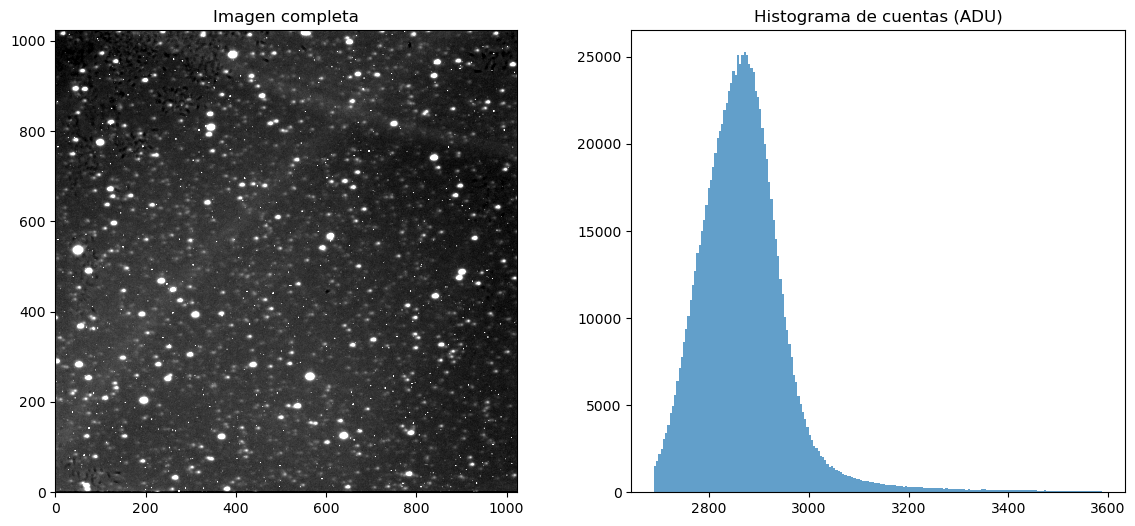

In [76]:
# Elegimos la primera imagen científica 
row = df[(df['imagetyp'] == 'object') & (df['object'] != 'bias') 
         & (df['object'] != 'skyflat') & (df['calibf'] != 'flat correction')].iloc[0]
img_path = night_dir / row['file']

# Leemos datos y header
with fits.open(img_path) as hdul:
    data = hdul[0].data.astype(float)
    header = hdul[0].header

print(f"Imagen seleccionada: {row['file']}")
print(f"OBJECT = {row['object']} | FILTER = {row['filters']} | EXPTIME = {row['exptime']} s")
print(f"Tamaño: {data.shape} píxeles | Tipo de dato: {data.dtype}")

# Estadísticos básicos MANUALES
mean_all   = np.mean(data)
median_all = np.median(data)
std_all    = np.std(data)
p5, p95    = np.percentile(data, [1, 99])

print(f"\n📈 Estadísticos MANUALES de toda la imagen:")
print(f"  Media   = {mean_all:.1f} ADU")
print(f"  Mediana = {median_all:.1f} ADU")
print(f"  Std     = {std_all:.1f} ADU")
print(f"  5%–95%  = {p5:.0f} – {p95:.0f} ADU")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
ax1.imshow(data, vmin=p5, vmax=p95)
ax1.set_title("Imagen completa")
ax2.hist(data.ravel(), bins=200, range=(p5, p95), alpha=0.7)
ax2.set_title("Histograma de cuentas (ADU)")
plt.show()

In [77]:
# Método 1: MANUAL (sigma clipping + mediana)
sigma_clip = SigmaClip(sigma=3.0, maxiters=5)
bkg_manual, bkg_median, _ = sigma_clipped_stats(data, sigma=3.0)
print(f"Fondo manual (sigma-clipped median) = {bkg_median:.2f} ADU")

# Método 2: photutils (el que usa la mayoría de pipelines serios)
bkg_estimator = ModeEstimatorBackground()
bkg_photutils = bkg_estimator.calc_background(data)
print(f"Fondo photutils (ModeEstimator)     = {bkg_photutils:.2f} ADU")

# Comparación
print(f"Diferencia = {abs(bkg_median - bkg_photutils):.3f} ADU → error en magnitud ≈ {2.5*np.log10(1 + 1/bkg_median):.4f} mag")

Fondo manual (sigma-clipped median) = 2860.80 ADU
Fondo photutils (ModeEstimator)     = 2862.16 ADU
Diferencia = 1.356 ADU → error en magnitud ≈ 0.0004 mag


FWHM manual ≈ 7.00 píxeles
Ver: 3.71 arcsec (escala típica CASLEO 0.53''/pix)


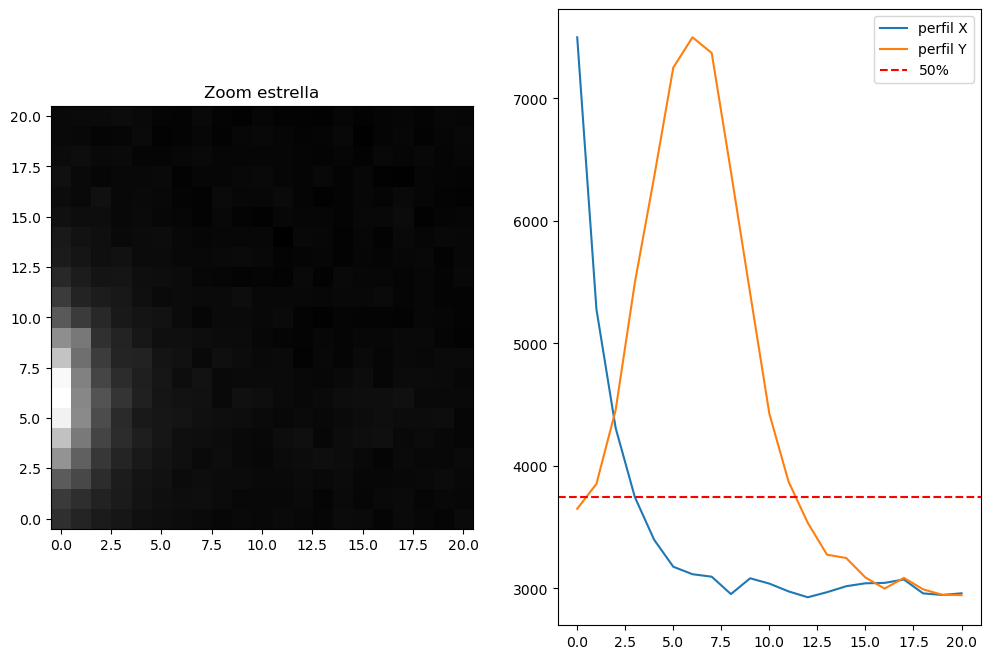

In [78]:
# ====================== CELDA 4 ======================
# Seleccionamos manualmente una estrella brillante (ejemplo: coordenadas en píxeles)
# Cambia estas coordenadas según tu imagen (usa DS9 o imshow para ver)
star_x, star_y = 580,260        # ← AJUSTA
box = 10

sub = data[int(star_y-box):int(star_y+box+1), int(star_x-box):int(star_x+box+1)]

# Centro aproximado (centro de masa)
yc, xc = np.unravel_index(np.argmax(sub), sub.shape)
amp = sub.max() - sub.min()

# FWHM aproximado (cuenta de píxeles > 50% altura)
half = 0.5 * sub.max()
profile_x = sub[int(yc), :]
profile_y = sub[:, int(xc)]
fwhm_x = np.sum(profile_x > half)
fwhm_y = np.sum(profile_y > half)
fwhm_manual = (fwhm_x + fwhm_y) / 2

print(f"FWHM manual ≈ {fwhm_manual:.2f} píxeles")
print(f"Ver: {fwhm_manual*0.53:.2f} arcsec (escala típica CASLEO 0.53''/pix)")

# Plot bonito
fig, ax = plt.subplots(1, 2)
ax[0].imshow(sub, origin='lower')
ax[0].set_title("Zoom estrella")
ax[1].plot(profile_x, label='perfil X')
ax[1].plot(profile_y, label='perfil Y')
ax[1].axhline(0.5*sub.max(), color='r', ls='--', label='50%')
ax[1].legend()
plt.show()

In [35]:
fwhm_x, fwhm_y, amp, sub.max(), sub.min(), (amp/2)+sub.min()

(6, 4, 932.0, 1065.0, 133.0, 599.0)

Fondo: 46.4 ± 9.89 ADU
→ Detectadas 23635 fuentes
→ Mediana FWHM (válidas) = 22.50 pix
   Media                 = 21.62 pix
   Std                   = 3.30 pix
   Fracción válida       = 95.1%


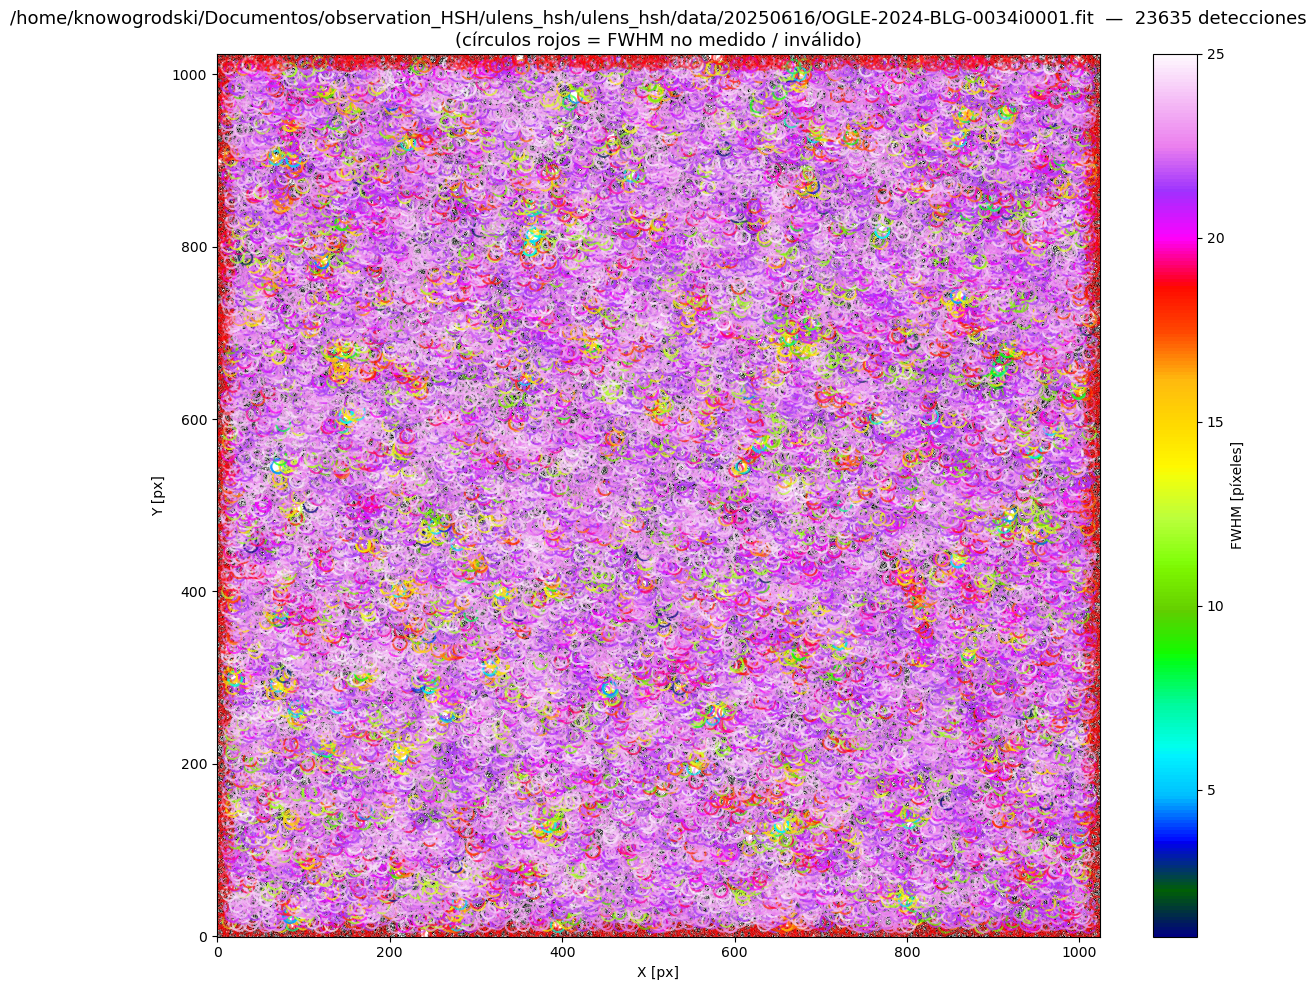

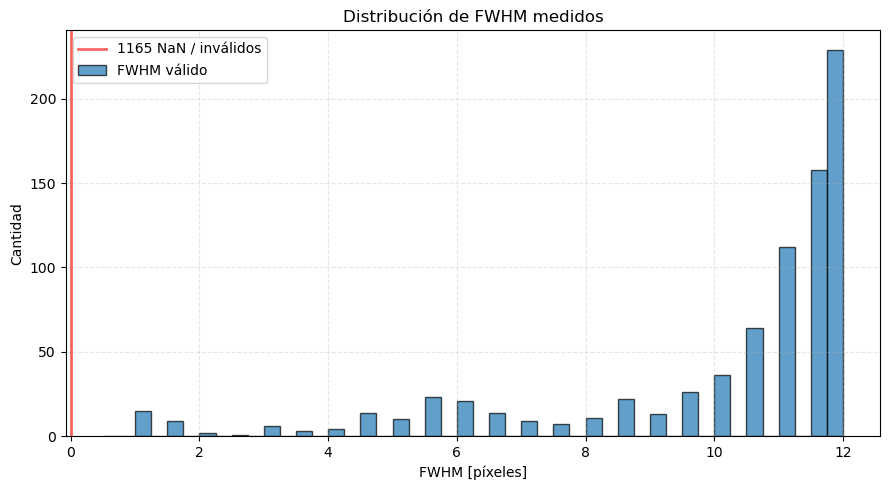

In [63]:
# =============================================================================
# CELDA: Detección + FWHM + visualización sobre la imagen + histograma
# =============================================================================
from photutils.detection import DAOStarFinder
from photutils.centroids import centroid_com
from astropy.stats import sigma_clipped_stats
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ── Parámetros ───────────────────────────────────────────────────────────────
threshold   = 3.0           # en múltiplos de std del fondo
fwhm_guess  = 3.0
sharp_lo    = 0.2
sharp_hi    = 1.0
round_lo    = -1.0
round_hi    = 1.0

# radio del círculo de visualización (en píxeles)
circle_radius_plot = 8.0

# ── Fondo y ruido ────────────────────────────────────────────────────────────
mean, median, std = sigma_clipped_stats(data, sigma=3.0)
print(f"Fondo: {median:.1f} ± {std:.2f} ADU")

# ── Detección ────────────────────────────────────────────────────────────────
daofind = DAOStarFinder(
    fwhm       = fwhm_guess,
    threshold  = threshold,
    sharplo    = sharp_lo,
    sharphi    = sharp_hi,
    roundlo    = round_lo,
    roundhi    = round_hi,
    sky        = median,
)

sources = daofind(data - median)

if sources is None or len(sources) == 0:
    print("✗ No se detectaron fuentes.")
else:
    print(f"→ Detectadas {len(sources)} fuentes")

    # ── Medir FWHM para cada fuente ──────────────────────────────────────────
    fwhm_values = []
    positions   = []

    for star in sources:
        x, y = star['xcentroid'], star['ycentroid']
        positions.append((x, y))

        # recorte
        cutout = data[int(y-12):int(y+13), int(x-12):int(x+13)]
        if cutout.size == 0 or cutout.shape != (25, 25):
            fwhm_values.append(np.nan)
            continue

        # centro refinado
        cy, cx = centroid_com(cutout)
        cy += int(y) - 12
        cx += int(x) - 12

        # perfiles
        prof_x = cutout[int(cy - (y-12)), :]
        prof_y = cutout[:, int(cx - (x-12))]

        peak_x = prof_x.max()
        peak_y = prof_y.max()

        if peak_x <= 0 or peak_y <= 0:
            fwhm_values.append(np.nan)
            continue

        fwhm_x = np.sum(prof_x > 0.5 * peak_x)
        fwhm_y = np.sum(prof_y > 0.5 * peak_y)

        fwhm_pix = (fwhm_x + fwhm_y) / 2.0
        fwhm_values.append(fwhm_pix)

    fwhm_arr = np.array(fwhm_values)

    # ── Estadísticos básicos (incluyendo NaN) ────────────────────────────────
    valid = ~np.isnan(fwhm_arr)
    if np.any(valid):
        med_fwhm = np.nanmedian(fwhm_arr)
        mean_fwhm = np.nanmean(fwhm_arr)
        std_fwhm  = np.nanstd(fwhm_arr)
        print(f"→ Mediana FWHM (válidas) = {med_fwhm:.2f} pix")
        print(f"   Media                 = {mean_fwhm:.2f} pix")
        print(f"   Std                   = {std_fwhm:.2f} pix")
        print(f"   Fracción válida       = {valid.mean():.1%}")
    else:
        print("No se midió ningún FWHM válido.")

    # ── Plot: imagen + círculos coloreados por FWHM ──────────────────────────
    fig = plt.figure(figsize=(14, 10))

    # imagen principal
    norm = plt.Normalize(vmin=np.percentile(data, 1), vmax=np.percentile(data, 99))
    plt.imshow(data, norm=norm, cmap='gray', interpolation='none')

    # colormap para FWHM
    if np.any(valid):
        norm_fwhm = Normalize(vmin=np.nanmin(fwhm_arr), vmax=np.nanmax(fwhm_arr))
        cmap = plt.cm.gist_ncar
        sm = ScalarMappable(cmap=cmap, norm=norm_fwhm)
        sm.set_array([])

        for (x, y), fwhm in zip(positions, fwhm_arr):
            if np.isnan(fwhm):
                color = 'red'           # NaN → rojo fuerte
                alpha = 0.4
            else:
                color = cmap(norm_fwhm(fwhm))
                alpha = 0.7

            circle = Circle((x, y), circle_radius_plot, edgecolor=color,
                            facecolor='none', lw=1.4, alpha=alpha)
            plt.gca().add_patch(circle)

        # barra de color
        cbar = plt.colorbar(sm, ax=plt.gca(), fraction=0.046, pad=0.04)
        cbar.set_label('FWHM [píxeles]')

    plt.title(f"{row['filename']}  —  {len(sources)} detecciones\n"
              f"(círculos rojos = FWHM no medido / inválido)", fontsize=13)
    plt.xlabel("X [px]")
    plt.ylabel("Y [px]")

    # zoom opcional (descomentar si querés inspeccionar una región)
    # plt.xlim(800, 1400)
    # plt.ylim(600, 1200)

    plt.tight_layout()
    plt.show()

    # ── Histograma de TODOS los FWHM (incluyendo NaN como valor especial) ────
    plt.figure(figsize=(9, 5))
    valid_fwhm = fwhm_arr[valid]
    if len(valid_fwhm) > 0:
        plt.hist(valid_fwhm, bins=np.arange(0.5, 12.1, 0.25),
                 color='C0', alpha=0.7, edgecolor='k', label='FWHM válido')
    if np.any(~valid):
        plt.axvline(0, color='red', lw=2, alpha=0.6, label=f'{(~valid).sum()} NaN / inválidos')
    plt.title("Distribución de FWHM medidos")
    plt.xlabel("FWHM [píxeles]")
    plt.ylabel("Cantidad")
    plt.grid(alpha=0.3, ls='--')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
img_path = 
with fits.open(img_path) as hdul:
    data = hdul[0].data.astype(float)
    header = hdul[0].header

print(f"Imagen seleccionada: {row['file']}")
print(f"OBJECT = {row['object']} | FILTER = {row['filters']} | EXPTIME = {row['exptime']} s")
print(f"Tamaño: {data.shape} píxeles | Tipo de dato: {data.dtype}")

# Estadísticos básicos MANUALES
mean_all   = np.mean(data)
median_all = np.median(data)
std_all    = np.std(data)
p5, p95    = np.percentile(data, [1, 99])

print(f"\n📈 Estadísticos MANUALES de toda la imagen:")
print(f"  Media   = {mean_all:.1f} ADU")
print(f"  Mediana = {median_all:.1f} ADU")
print(f"  Std     = {std_all:.1f} ADU")
print(f"  5%–95%  = {p5:.0f} – {p95:.0f} ADU")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))
ax1.imshow(data, vmin=p5, vmax=p95)
ax1.set_title("Imagen completa")
ax2.hist(data.ravel(), bins=200, range=(p5, p95), alpha=0.7)
ax2.set_title("Histograma de cuentas (ADU)")
plt.show()